In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow version:', tf.__version__)
print('Abhishek V Ammanagi | 2023BCSE07AED500')
print('Experiment 12: LSTM Air Temperature Forecasting')

TensorFlow version: 2.20.0
Abhishek V Ammanagi | 2023BCSE07AED500
Experiment 12: LSTM Air Temperature Forecasting


In [2]:
# ── Configuration ────────────────────────────────────────────
SEQ_LEN    = 60     # Look-back window (days)
FORECAST   = 1      # Steps ahead to predict
EPOCHS     = 50
BATCH_SIZE = 32
np.random.seed(42)
tf.random.set_seed(42)

Dataset length : 1825 days (~5 years)
Temp range     : [3.36, 44.49] °C
Mean temp      : 23.89 °C


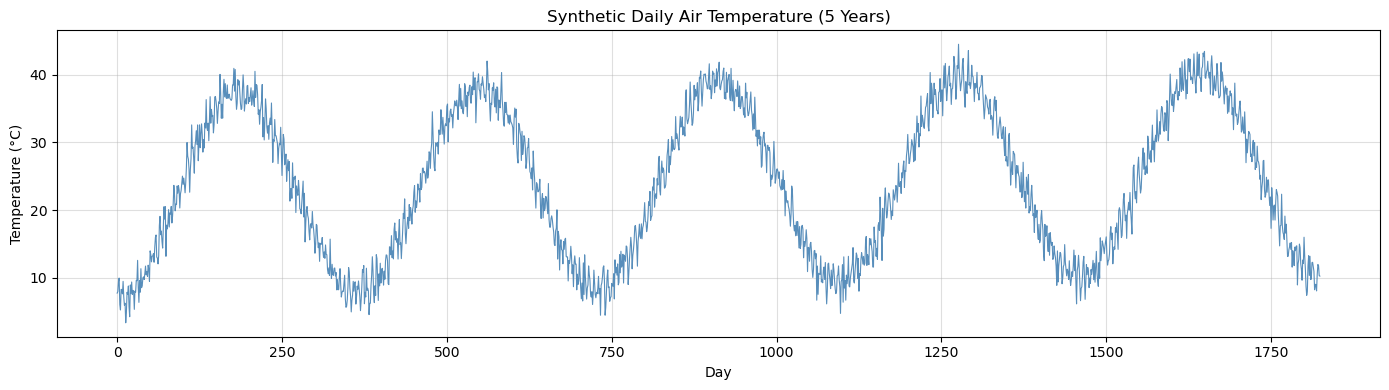

In [3]:
# ── Synthetic Air Temperature Dataset ───────────────────────
# Simulates 5 years of daily temperatures with:
#   - Annual seasonality (sine wave)
#   - Weekly micro-cycle
#   - Gaussian noise
#   - Slow upward trend (climate drift)

n_days = 365 * 5   # 1825 data points
t      = np.arange(n_days)

annual_cycle  = 15 * np.sin(2 * np.pi * t / 365 - np.pi / 2)
weekly_cycle  = 1.5 * np.sin(2 * np.pi * t / 7)
trend         = 0.002 * t                         # +0.002°C per day
noise         = np.random.normal(0, 1.5, n_days)

base_temp     = 22.0   # Average temperature in Celsius
temperature   = base_temp + annual_cycle + weekly_cycle + trend + noise

print(f'Dataset length : {n_days} days (~5 years)')
print(f'Temp range     : [{temperature.min():.2f}, {temperature.max():.2f}] °C')
print(f'Mean temp      : {temperature.mean():.2f} °C')

# Plot the full temperature series
plt.figure(figsize=(14, 4))
plt.plot(temperature, color='steelblue', linewidth=0.8, alpha=0.9)
plt.title('Synthetic Daily Air Temperature (5 Years)')
plt.xlabel('Day'); plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

In [4]:
# ── Normalise & Create Sequences ─────────────────────────────
scaler   = MinMaxScaler(feature_range=(0, 1))
temp_norm = scaler.fit_transform(temperature.reshape(-1, 1)).flatten()

def create_sequences(data, seq_len, forecast=1):
    X, y = [], []
    for i in range(len(data) - seq_len - forecast + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len : i + seq_len + forecast])
    return np.array(X), np.array(y)

X, y = create_sequences(temp_norm, SEQ_LEN, FORECAST)
X    = X.reshape(-1, SEQ_LEN, 1)
y    = y.reshape(-1, FORECAST)

# 80/20 Train-Test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Total sequences : {len(X)}')
print(f'Train sequences : {len(X_train)}')
print(f'Test  sequences : {len(X_test)}')
print(f'Input shape     : {X_train.shape}')
print(f'Output shape    : {y_train.shape}')

Total sequences : 1765
Train sequences : 1412
Test  sequences : 353
Input shape     : (1412, 60, 1)
Output shape    : (1412, 1)


In [5]:
# ── Build LSTM Model ─────────────────────────────────────────
model = models.Sequential([
    # First LSTM layer — returns sequences for stacking
    layers.LSTM(128, input_shape=(SEQ_LEN, 1),
                return_sequences=True,
                name='LSTM_1'),
    layers.Dropout(0.2),

    # Second LSTM layer
    layers.LSTM(64, return_sequences=True, name='LSTM_2'),
    layers.Dropout(0.2),

    # Third LSTM layer — final recurrent output
    layers.LSTM(32, name='LSTM_3'),
    layers.Dropout(0.2),

    # Dense head
    layers.Dense(16, activation='relu'),
    layers.Dense(FORECAST, name='Output')
], name='Air_Temp_LSTM')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "Air_Temp_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ── Train Model ──────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_reduce  = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split = 0.1,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    callbacks        = [early_stop, lr_reduce],
    verbose          = 1
)

print(f'\nTraining stopped at epoch: {len(history.history["loss"])}')

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 0.0503 - mae: 0.1566 - val_loss: 0.0077 - val_mae: 0.0751 - learning_rate: 0.0010
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0113 - mae: 0.0819 - val_loss: 0.0024 - val_mae: 0.0394 - learning_rate: 0.0010
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0080 - mae: 0.0698 - val_loss: 0.0030 - val_mae: 0.0443 - learning_rate: 0.0010
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0063 - mae: 0.0617 - val_loss: 0.0024 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0059 - mae: 0.0594 - val_loss: 0.0025 - val_mae: 0.0396 - learning_rate: 0.0010
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0054 - mae: 0.0568 - val_loss: 0.0034 - val_mae: 0.0461 - learning_rate: 0.0010
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0056 - mae: 0.0575 - val_loss: 0.0023 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 8/50
40

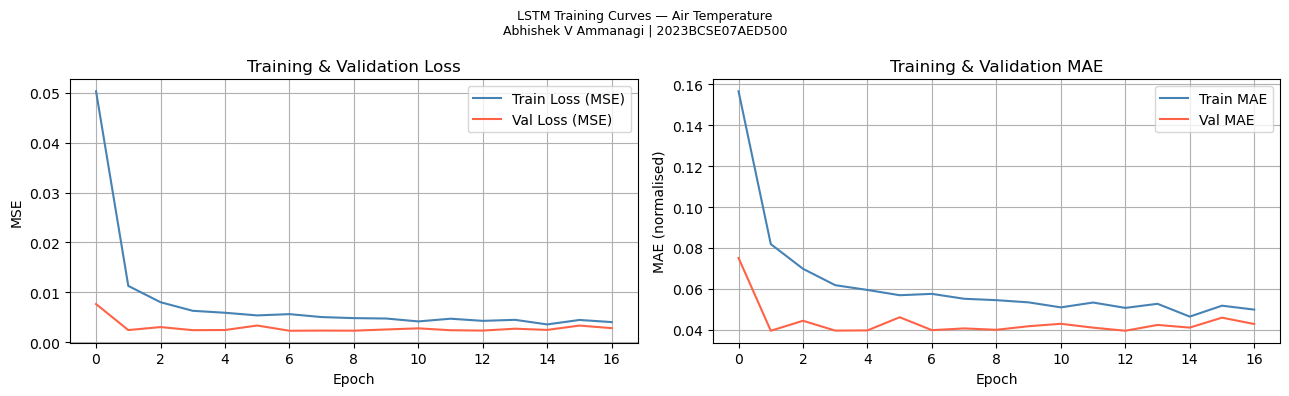

In [7]:
# ── Plot Training Curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss (MSE)', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss (MSE)',   color='tomato')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato')
axes[1].set_title('Training & Validation MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (normalised)')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('LSTM Training Curves — Air Temperature\n'
             'Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=9)
plt.tight_layout()
plt.savefig('exp12_training_curves.png', dpi=200)
plt.show()

In [8]:
# ── Predict & Inverse-Transform ──────────────────────────────
y_pred_norm = model.predict(X_test, verbose=0)

# Inverse scale back to °C
y_pred_actual = scaler.inverse_transform(y_pred_norm)
y_test_actual = scaler.inverse_transform(y_test)

# Flatten for metric calculation
y_pred_flat = y_pred_actual.flatten()
y_test_flat = y_test_actual.flatten()

# ── Evaluation Metrics ───────────────────────────────────────
mae  = mean_absolute_error(y_test_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
mape = np.mean(np.abs((y_test_flat - y_pred_flat) /
                      (np.abs(y_test_flat) + 1e-8))) * 100

# R² score
ss_res = np.sum((y_test_flat - y_pred_flat) ** 2)
ss_tot = np.sum((y_test_flat - y_test_flat.mean()) ** 2)
r2     = 1 - ss_res / ss_tot

print('=' * 50)
print('  Evaluation on Test Set')
print('=' * 50)
print(f'  MAE  : {mae:.4f} °C')
print(f'  RMSE : {rmse:.4f} °C')
print(f'  MAPE : {mape:.2f} %')
print(f'  R²   : {r2:.4f}')
print('=' * 50)

  Evaluation on Test Set
  MAE  : 1.8270 °C
  RMSE : 2.2755 °C
  MAPE : 8.35 %
  R²   : 0.9544


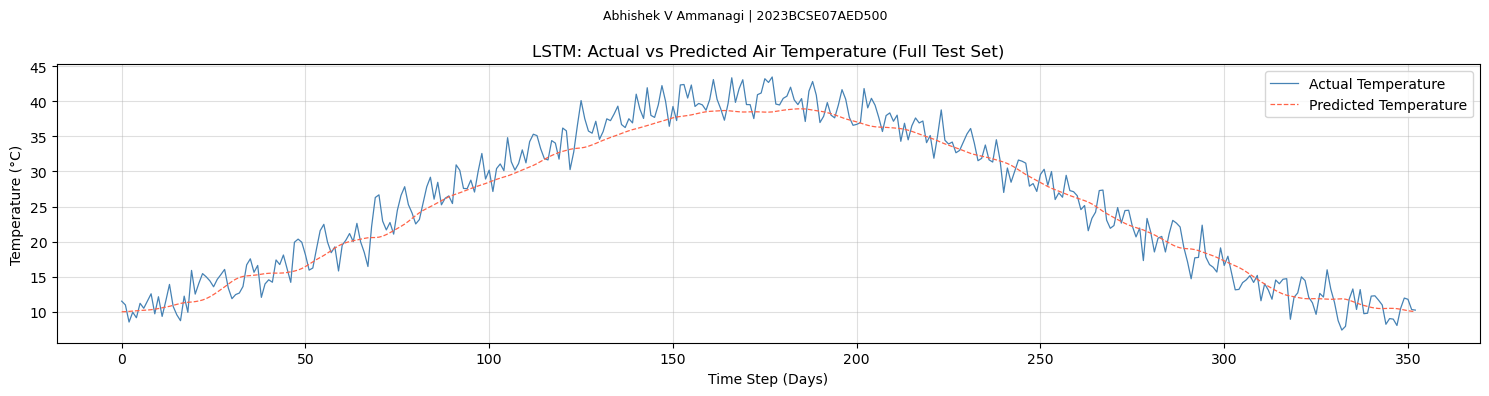

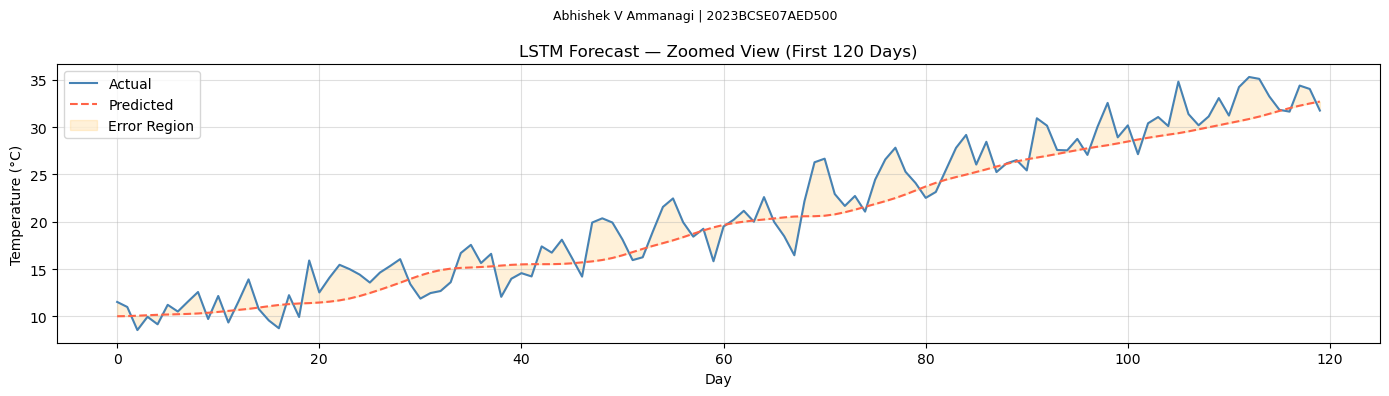

In [9]:
# ── Actual vs Predicted — Full Test Set ──────────────────────
plt.figure(figsize=(15, 4))
plt.plot(y_test_flat,  label='Actual Temperature',    color='steelblue', linewidth=0.9)
plt.plot(y_pred_flat,  label='Predicted Temperature', color='tomato',    linewidth=0.9, linestyle='--')
plt.title('LSTM: Actual vs Predicted Air Temperature (Full Test Set)')
plt.xlabel('Time Step (Days)'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(True, alpha=0.4)
plt.suptitle('Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=9)
plt.tight_layout()
plt.savefig('exp12_full_prediction.png', dpi=200)
plt.show()

# ── Zoomed View — First 120 Days ─────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(y_test_flat[:120],  label='Actual',    color='steelblue', linewidth=1.5)
plt.plot(y_pred_flat[:120],  label='Predicted', color='tomato',    linewidth=1.5, linestyle='--')
plt.fill_between(range(120),
                 y_test_flat[:120], y_pred_flat[:120],
                 alpha=0.15, color='orange', label='Error Region')
plt.title('LSTM Forecast — Zoomed View (First 120 Days)')
plt.xlabel('Day'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.grid(True, alpha=0.4)
plt.suptitle('Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=9)
plt.tight_layout()
plt.savefig('exp12_zoomed_prediction.png', dpi=200)
plt.show()

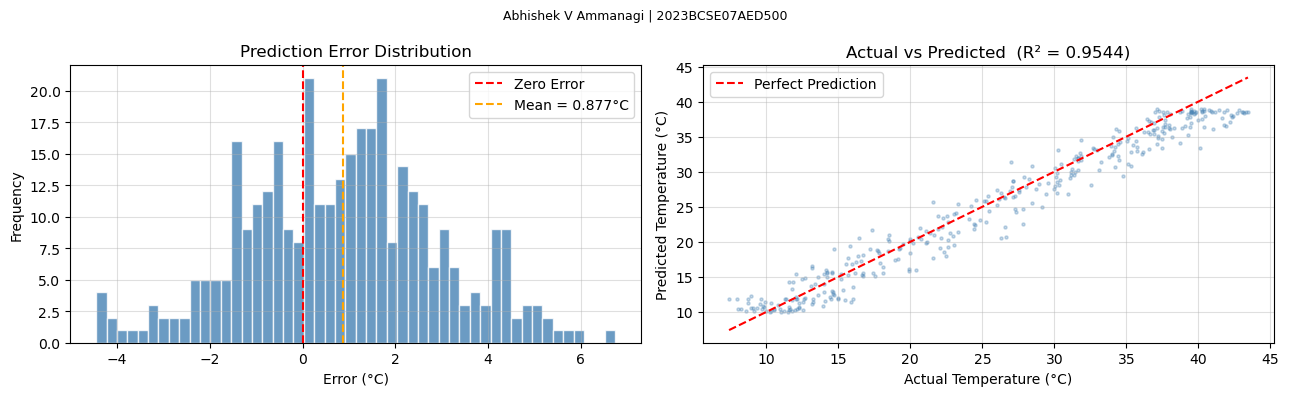

In [10]:
# ── Prediction Error Distribution ────────────────────────────
errors = y_test_flat - y_pred_flat

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', label='Zero Error')
axes[0].axvline(errors.mean(), color='orange', linestyle='--',
                label=f'Mean = {errors.mean():.3f}°C')
axes[0].set_title('Prediction Error Distribution')
axes[0].set_xlabel('Error (°C)'); axes[0].set_ylabel('Frequency')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].scatter(y_test_flat, y_pred_flat, alpha=0.3, s=5, color='steelblue')
lims = [min(y_test_flat.min(), y_pred_flat.min()),
        max(y_test_flat.max(), y_pred_flat.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect Prediction')
axes[1].set_title(f'Actual vs Predicted  (R² = {r2:.4f})')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Abhishek V Ammanagi | 2023BCSE07AED500', fontsize=9)
plt.tight_layout()
plt.savefig('exp12_error_analysis.png', dpi=200)
plt.show()

In [11]:
# ── Final Summary ─────────────────────────────────────────────
print('=' * 60)
print('  Experiment 12 — LSTM Air Temperature Forecasting')
print('  Abhishek V Ammanagi | 2023BCSE07AED500')
print('=' * 60)
print(f'  Sequence Length (look-back) : {SEQ_LEN} days')
print(f'  Forecast Horizon            : {FORECAST} day(s) ahead')
print(f'  Training Epochs (actual)    : {len(history.history["loss"])}')
print()
print('  Metrics on Test Set:')
print(f'    MAE  = {mae:.4f} °C  (avg absolute error per day)')
print(f'    RMSE = {rmse:.4f} °C  (penalises large errors more)')
print(f'    MAPE = {mape:.2f} %')
print(f'    R²   = {r2:.4f}')
print()
print('  Result: The stacked LSTM network successfully learned')
print('  seasonal temperature patterns. Low MAE/RMSE and high R²')
print('  confirm accurate forecasts suitable for environmental')
print('  and urban planning applications.')
print('=' * 60)

  Experiment 12 — LSTM Air Temperature Forecasting
  Abhishek V Ammanagi | 2023BCSE07AED500
  Sequence Length (look-back) : 60 days
  Forecast Horizon            : 1 day(s) ahead
  Training Epochs (actual)    : 17

  Metrics on Test Set:
    MAE  = 1.8270 °C  (avg absolute error per day)
    RMSE = 2.2755 °C  (penalises large errors more)
    MAPE = 8.35 %
    R²   = 0.9544

  Result: The stacked LSTM network successfully learned
  seasonal temperature patterns. Low MAE/RMSE and high R²
  confirm accurate forecasts suitable for environmental
  and urban planning applications.
